# Cardiovascular Disease — Classical Tabular ResNet18 Baseline

Kaggle dataset: **Cardiovascular Disease Dataset** by Svetlana Ulianova.

This notebook is the cardiovascular counterpart of the earlier Diabetes Health Indicators baseline.

### Fair-comparison design

- Same **ResNet18-style [2,2,2,2] residual architecture** used for the diabetes CSV experiment.
- Same **70/15/15 stratified split**.
- Same train-only `StandardScaler`.
- Same optimizer, learning rate, early stopping, and metrics.
- No target leakage.
- Exact duplicate records are removed before splitting.

A standard torchvision ResNet18 is an image CNN, so this notebook uses a **tabular ResNet18-style residual MLP**, which is the correct CSV analogue.

In [1]:
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

from pathlib import Path
from datetime import datetime, timezone

SEED = 42
BATCH_SIZE = 256
EPOCHS = 30
LR = 1e-3
PATIENCE = 5
NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

RUN_DIR = Path("/kaggle/working") / (
    "cardiovascular_baseline_tabular_resnet18_" +
    datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
)
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("Output:", RUN_DIR)

Device: cuda
Output: /kaggle/working/cardiovascular_baseline_tabular_resnet18_20260903_152221


## 1. Load `cardio_train.csv`

The original Kaggle file is usually semicolon-delimited. This cell searches `/kaggle/input` recursively and automatically handles either `;` or `,`.

In [2]:
from pathlib import Path

matches = list(Path("/kaggle/input").rglob("cardio_train.csv"))
if not matches:
    # Fallback for renamed copies
    candidates = list(Path("/kaggle/input").rglob("*.csv"))
    print("CSV files found:", [str(p) for p in candidates[:20]])
    raise FileNotFoundError(
        "Could not find cardio_train.csv. Add the Cardiovascular Disease Dataset "
        "by Svetlana Ulianova to this Kaggle notebook."
    )

CSV_PATH = matches[0]

# Kaggle's original file uses ';'. sep=None makes the loader robust to copies using ','.
df = pd.read_csv(CSV_PATH, sep=None, engine="python")

print("CSV:", CSV_PATH)
print("Raw shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())
print("\nMissing values:", int(df.isna().sum().sum()))

CSV: /kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv
Raw shape: (70000, 13)
Columns: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0



Missing values: 0


## 2. Prepare features

Dataset target: **`cardio`**
- `0` = absence of cardiovascular disease
- `1` = presence of cardiovascular disease

`id` is only a row identifier, so it is removed.

`age` is stored in **days** in the original dataset. We convert it to years for interpretability; standardization later handles its numerical scale.

No target-derived features are created.

In [3]:
TARGET = "cardio"

if TARGET not in df.columns:
    raise ValueError(f"Expected target column '{TARGET}', got {df.columns.tolist()}")

work = df.copy()

if "id" in work.columns:
    work = work.drop(columns=["id"])

if "age" in work.columns:
    work["age"] = work["age"] / 365.25

# Drop exact duplicate rows only BEFORE splitting.
# This avoids putting identical patient records in both train and test.
before = len(work)
work = work.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(work)} exact duplicate rows.")
print("Usable rows:", len(work))

X_df = work.drop(columns=[TARGET]).copy()
y = work[TARGET].astype(int).to_numpy()

if not all(np.issubdtype(dtype, np.number) for dtype in X_df.dtypes):
    bad = X_df.select_dtypes(exclude=[np.number]).columns.tolist()
    raise ValueError(f"Non-numeric columns found: {bad}")

feature_names = X_df.columns.tolist()
X = X_df.to_numpy(dtype=np.float32)

classes = np.unique(y)
if not np.array_equal(classes, np.array([0, 1])):
    raise ValueError(f"Expected binary labels [0,1], got {classes}")

NUM_CLASSES = 2

print("Features:", feature_names)
print("Number of features:", len(feature_names))
print("\nClass distribution:")
print(pd.Series(y).value_counts().sort_index())
print("\nClass proportions:")
print(pd.Series(y).value_counts(normalize=True).sort_index())

Removed 24 exact duplicate rows.
Usable rows: 69976
Features: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
Number of features: 11

Class distribution:
0    35004
1    34972
Name: count, dtype: int64

Class proportions:
0    0.500229
1    0.499771
Name: proportion, dtype: float64


## 3. Stratified 70/15/15 split and train-only standardization

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (48983, 11)
Val:   (10496, 11)
Test:  (10497, 11)


In [5]:
def make_loader(X_arr, y_arr, shuffle):
    ds = TensorDataset(
        torch.from_numpy(X_arr),
        torch.from_numpy(y_arr).long()
    )
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda")
    )

train_loader = make_loader(X_train, y_train, True)
val_loader = make_loader(X_val, y_val, False)
test_loader = make_loader(X_test, y_test, False)

print("Batches:", len(train_loader), len(val_loader), len(test_loader))

Batches: 192 41 42


## 4. Tabular ResNet18 baseline

Pipeline:

`clinical features → stem → layer1 → layer2 → layer3 → layer4 → binary classifier`

The residual stage counts are **[2, 2, 2, 2]**, matching the block organization of ResNet18.

In [6]:
class ResidualMLPBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.10):
        super().__init__()

        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim)

        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)

        self.dropout = nn.Dropout(dropout)
        self.skip = (
            nn.Identity()
            if in_dim == out_dim
            else nn.Linear(in_dim, out_dim)
        )

    def forward(self, x):
        identity = self.skip(x)

        out = self.fc1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.dropout(out)

        out = self.fc2(out)
        out = self.bn2(out)

        return F.relu(out + identity)


class TabularResNet18(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        self.layer1 = nn.Sequential(
            ResidualMLPBlock(64, 64),
            ResidualMLPBlock(64, 64)
        )

        self.layer2 = nn.Sequential(
            ResidualMLPBlock(64, 128),
            ResidualMLPBlock(128, 128)
        )

        self.layer3 = nn.Sequential(
            ResidualMLPBlock(128, 256),
            ResidualMLPBlock(256, 256)
        )

        self.layer4 = nn.Sequential(
            ResidualMLPBlock(256, 512),
            ResidualMLPBlock(512, 512)
        )

        self.head = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return self.head(x)


model = TabularResNet18(
    input_dim=X_train.shape[1],
    num_classes=NUM_CLASSES
).to(DEVICE)

print(model)

with torch.no_grad():
    smoke = model(
        torch.randn(8, X_train.shape[1], device=DEVICE)
    )
    assert smoke.shape == (8, 2)

print("PASS: output shape =", tuple(smoke.shape))

TabularResNet18(
  (stem): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer1): Sequential(
    (0): ResidualMLPBlock(
      (fc1): Linear(in_features=64, out_features=64, bias=True)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (fc2): Linear(in_features=64, out_features=64, bias=True)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (skip): Identity()
    )
    (1): ResidualMLPBlock(
      (fc1): Linear(in_features=64, out_features=64, bias=True)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (fc2): Linear(in_features=64, out_features=64, bias=True)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (d

## Metrics

In [7]:
def compute_metrics(labels, probs):
    preds = probs.argmax(axis=1)

    cm = confusion_matrix(labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision_macro": precision_score(labels, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(labels, preds, average="macro", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(labels, probs[:, 1]),
        "sensitivity": tp / (tp + fn) if (tp + fn) else float("nan"),
        "specificity": tn / (tn + fp) if (tn + fp) else float("nan"),
    }

## Training with validation macro-F1 early stopping

In [8]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    probs_list, labels_list = [], []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        probs_list.append(F.softmax(logits, dim=1).cpu().numpy())
        labels_list.append(yb.cpu().numpy())

    probs = np.concatenate(probs_list)
    labels = np.concatenate(labels_list)

    metrics = {"loss": total_loss / len(loader.dataset)}
    metrics.update(compute_metrics(labels, probs))

    return metrics, probs, labels


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

best_f1 = -1.0
best_epoch = 0
best_state = None
stale = 0
history = []

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_metrics, _, _ = evaluate(model, val_loader, criterion)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()}
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['accuracy']:.4f} | "
        f"val_f1={val_metrics['f1_macro']:.4f} | "
        f"{time.time()-t0:.1f}s"
    )

    if val_metrics["f1_macro"] > best_f1 + 1e-4:
        best_f1 = val_metrics["f1_macro"]
        best_epoch = epoch
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        stale = 0
    else:
        stale += 1
        if stale >= PATIENCE:
            print("Early stopping.")
            break

model.load_state_dict(best_state)
pd.DataFrame(history).to_csv(RUN_DIR / "training_history.csv", index=False)

print("Best epoch:", best_epoch)
print("Best validation macro-F1:", best_f1)

Epoch 01 | train_loss=0.6377 | val_loss=0.5842 | val_acc=0.7019 | val_f1=0.7013 | 2.8s
Epoch 02 | train_loss=0.5805 | val_loss=0.5736 | val_acc=0.7099 | val_f1=0.7084 | 2.5s
Epoch 03 | train_loss=0.5662 | val_loss=0.6199 | val_acc=0.6420 | val_f1=0.6190 | 2.6s
Epoch 04 | train_loss=0.5594 | val_loss=0.5595 | val_acc=0.7233 | val_f1=0.7232 | 2.5s
Epoch 05 | train_loss=0.5553 | val_loss=0.5728 | val_acc=0.7194 | val_f1=0.7189 | 2.6s
Epoch 06 | train_loss=0.5529 | val_loss=0.5597 | val_acc=0.7232 | val_f1=0.7232 | 2.4s
Epoch 07 | train_loss=0.5510 | val_loss=0.5929 | val_acc=0.6890 | val_f1=0.6797 | 2.5s
Epoch 08 | train_loss=0.5511 | val_loss=0.6195 | val_acc=0.6328 | val_f1=0.6065 | 2.5s
Epoch 09 | train_loss=0.5488 | val_loss=0.5754 | val_acc=0.7058 | val_f1=0.7027 | 2.4s
Early stopping.
Best epoch: 4
Best validation macro-F1: 0.7232417756990744


## Final validation and held-out test results

In [9]:
results = []

for split_name, loader in [("validation", val_loader), ("test", test_loader)]:
    metrics, probs, labels = evaluate(model, loader, criterion)
    preds = probs.argmax(axis=1)

    print(f"\n=== {split_name.upper()} ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    print("\nClassification report:")
    print(classification_report(labels, preds, digits=4, zero_division=0))

    results.append({"split": split_name, **metrics})

    pred_df = pd.DataFrame({
        "true_label": labels,
        "predicted_label": preds,
        "prob_class_0": probs[:, 0],
        "prob_class_1": probs[:, 1],
    })
    pred_df.to_csv(RUN_DIR / f"{split_name}_predictions.csv", index=False)

results_df = pd.DataFrame(results)
display(results_df)
results_df.to_csv(RUN_DIR / "metrics.csv", index=False)


=== VALIDATION ===
loss: 0.5595
accuracy: 0.7233
precision_macro: 0.7236
recall_macro: 0.7233
f1_macro: 0.7232
roc_auc: 0.7896
sensitivity: 0.7064
specificity: 0.7402

Classification report:
              precision    recall  f1-score   support

           0     0.7162    0.7402    0.7280      5250
           1     0.7310    0.7064    0.7185      5246

    accuracy                         0.7233     10496
   macro avg     0.7236    0.7233    0.7232     10496
weighted avg     0.7236    0.7233    0.7232     10496


=== TEST ===
loss: 0.5636
accuracy: 0.7244
precision_macro: 0.7248
recall_macro: 0.7244
f1_macro: 0.7243
roc_auc: 0.7868
sensitivity: 0.7032
specificity: 0.7456

Classification report:
              precision    recall  f1-score   support

           0     0.7155    0.7456    0.7302      5251
           1     0.7341    0.7032    0.7183      5246

    accuracy                         0.7244     10497
   macro avg     0.7248    0.7244    0.7243     10497
weighted avg     0.7248

,split,loss,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,sensitivity,specificity
0,validation,0.559481,0.723323,0.723574,0.723317,0.723242,0.789618,0.706443,0.740190
1,test,0.563554,0.724397,0.724795,0.724387,0.724270,0.786789,0.703202,0.745572


## Training curves

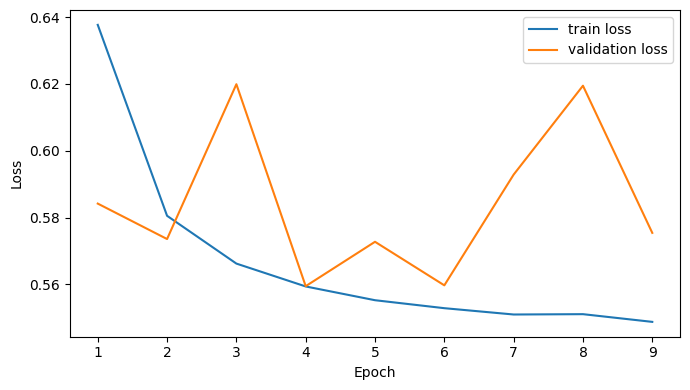

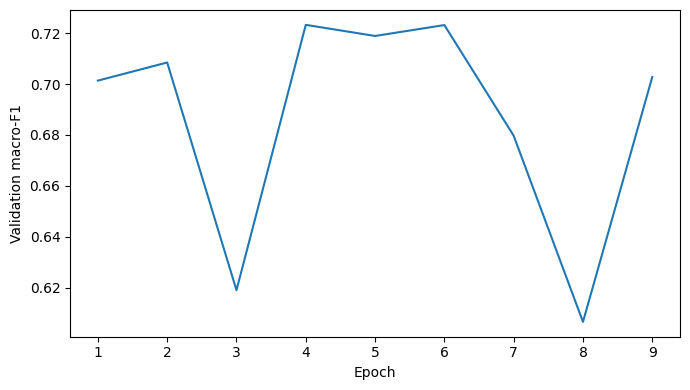

In [10]:
hist = pd.DataFrame(history)

plt.figure(figsize=(7, 4))
plt.plot(hist["epoch"], hist["train_loss"], label="train loss")
plt.plot(hist["epoch"], hist["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(hist["epoch"], hist["val_f1_macro"])
plt.xlabel("Epoch")
plt.ylabel("Validation macro-F1")
plt.tight_layout()
plt.show()

## Export deployment artifacts\n\nExports the restored best-validation checkpoint, the exact train-fitted scaler, and backend reconstruction metadata.\n

In [11]:
# Export the restored best-validation model and its exact training scaler.
import joblib
import shutil

DEPLOY_DIR = Path("/kaggle/working/cardiovascular_backend_model")
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = DEPLOY_DIR / "cardiovascular_model.pth"
SCALER_PATH = DEPLOY_DIR / "cardiovascular_scaler.pkl"
CONFIG_PATH = DEPLOY_DIR / "cardiovascular_config.json"
ZIP_PATH = Path("/kaggle/working/cardiovascular_backend_model.zip")

# `model` was restored from best_state after validation-macro-F1 early stopping.
torch.save(model.state_dict(), MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

config = {
    "model_name": "TabularResNet18",
    "architecture": {
        "type": "Tabular ResNet18-style residual MLP",
        "residual_block": "ResidualMLPBlock",
        "stem": {"input": len(feature_names), "output": 64},
        "layer1": [[64, 64], [64, 64]],
        "layer2": [[64, 128], [128, 128]],
        "layer3": [[128, 256], [256, 256]],
        "layer4": [[256, 512], [512, 512]],
        "head": [512, NUM_CLASSES],
        "batch_norm": True,
        "output": "raw logits for two classes",
    },
    "input_dimension": len(feature_names),
    "num_classes": NUM_CLASSES,
    "feature_names": feature_names,
    "target_name": TARGET,
    "age_preprocessing": {
        "source_unit": "days",
        "operation": "age / 365.25",
        "output_unit": "years",
    },
    "id_column": {"name": "id", "action": "remove"},
    "class_mapping": {
        "0": "No cardiovascular disease",
        "1": "Cardiovascular disease",
    },
    "scaler_type": "sklearn.preprocessing.StandardScaler",
    "dropout": 0.10,
    "best_epoch": best_epoch,
    "seed": SEED,
}
CONFIG_PATH.write_text(json.dumps(config, indent=2), encoding="utf-8")

if ZIP_PATH.exists():
    ZIP_PATH.unlink()
shutil.make_archive(
    str(ZIP_PATH.with_suffix("")),
    "zip",
    root_dir=DEPLOY_DIR.parent,
    base_dir=DEPLOY_DIR.name,
)

print("Deployment files:")
for path in (MODEL_PATH, SCALER_PATH, CONFIG_PATH, ZIP_PATH):
    print(path.resolve())
print(f"Download this ZIP from Kaggle: {ZIP_PATH.resolve()}")


Saved outputs to: /kaggle/working/cardiovascular_baseline_tabular_resnet18_20260903_152221


## Deployment verification smoke test\n

In [ ]:
# Deployment smoke test: load CPU artifacts and reproduce the trained model output.
reloaded_config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
reloaded_scaler = joblib.load(SCALER_PATH)

reloaded_model = TabularResNet18(
    input_dim=reloaded_config["input_dimension"],
    num_classes=reloaded_config["num_classes"],
)
reloaded_model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
reloaded_model.eval()

# Start from an unprocessed row and repeat the deployed preprocessing rules exactly.
raw_sample = df.iloc[[0]].copy()
sample_features = raw_sample.drop(columns=[reloaded_config["target_name"]], errors="ignore")
sample_features = sample_features.drop(columns=[reloaded_config["id_column"]["name"]], errors="ignore")
if "age" in sample_features.columns:
    sample_features["age"] = sample_features["age"] / 365.25
sample_features = sample_features.loc[:, reloaded_config["feature_names"]]

scaled_sample = reloaded_scaler.transform(
    sample_features.to_numpy(dtype=np.float32)
).astype(np.float32)
sample_tensor_cpu = torch.from_numpy(scaled_sample)

model.eval()
with torch.no_grad():
    original_logits = model(sample_tensor_cpu.to(DEVICE)).cpu()
    reloaded_logits = reloaded_model(sample_tensor_cpu)
    probabilities = torch.softmax(reloaded_logits, dim=1)

np.testing.assert_allclose(
    original_logits.numpy(), reloaded_logits.numpy(), rtol=1e-5, atol=1e-6
)
predicted_class = int(probabilities.argmax(dim=1).item())
print("Smoke test passed: reloaded CPU model matches the restored best model.")
print("Predicted class:", predicted_class)
print("Probability of class 0:", float(probabilities[0, 0]))
print("Probability of class 1:", float(probabilities[0, 1]))
